<a href="https://colab.research.google.com/github/Ogbz/MatlabQuadSimAP/blob/master/Formular_1_Car_Racing_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# """
# =============================================================================
#   Formular 1 Racing Car:  4-State Linear State-Space Model with LQR Tracking Control
# =============================================================================
#   System:   ẋ = Ax + Bu + d(t)
#   States:   x = [x1, x2, x3, x4]
#   Control:  U = [u1, u2, u3, u4]  (LQR computed per channel)
#   Desired:  x_d = step-wise reference trajectory
#   Disturb:  d_i(t) = A_i·sin(wᵢ·t),  w = [2, 4, 6, 8] rad/s
#   Outputs:  tracking error, control input magnitudes, and RMSE
# =============================================================================
# """

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import solve_continuous_are   # Algebraic Riccati Equation
from scipy.integrate import solve_ivp           # Runge-Kutta ODE integrator

In [53]:
# Pretty LaTeX-style math in axis labels

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 130,
})

COLORS = ["#2563EB", "#16A34A", "#DC2626", "#9333EA"]   # blue, green, red, purple

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 – SYSTEM MATRICES  A and B
# ─────────────────────────────────────────────────────────────────────────────
#
# The UAV is modelled as four decoupled first-order channels.
# Each channel i obeys:   ẋᵢ = aᵢ·xᵢ + bᵢ·uᵢ + dᵢ(t)
#
# Choosing aᵢ < 0 makes each channel open-loop stable (the UAV drifts
# back toward zero without control).  In practice aᵢ encodes aerodynamic
# drag, aᵢ = -drag_coeff / inertia.
#
# bᵢ > 0 is the actuator effectiveness (thrust, torque) divided by
# the relevant inertia/mass.  Larger bᵢ means "more responsive".

a_diag = np.array([-1.0, -1.5, -2.0, -2.5])   # system eigenvalues (open-loop poles)
b_diag = np.array([ 2.0,  3.0,  2.5,  4.0])   # control effectiveness

A = np.diag(a_diag)   # 4×4 diagonal system matrix
B = np.diag(b_diag)   # 4×4 diagonal input matrix

print("=" * 60)
print(" THE SYSTEM STATE-SPACE MATRICES")
print("=" * 60)
print(f"A (system matrix) =\n{A}\n")
print(f"B (input matrix)  =\n{B}\n")

 THE SYSTEM STATE-SPACE MATRICES
A (system matrix) =
[[-1.   0.   0.   0. ]
 [ 0.  -1.5  0.   0. ]
 [ 0.   0.  -2.   0. ]
 [ 0.   0.   0.  -2.5]]

B (input matrix)  =
[[2.  0.  0.  0. ]
 [0.  3.  0.  0. ]
 [0.  0.  2.5 0. ]
 [0.  0.  0.  4. ]]



In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 – LQR DESIGN
# ─────────────────────────────────────────────────────────────────────────────
# LQR minimises the infinite-horizon cost:
#
#   J = ∫₀^∞  [ e(t)ᵀ Q e(t)  +  u(t)ᵀ R u(t) ] dt
#
# where  e(t) = x(t) - x_d(t)  is the tracking error.
#
# Tuning rules of thumb
# ─────────────────────
#   Q  : penalises large tracking error.  Increase Qᵢᵢ for tighter tracking on channel i (at the cost of larger control effort).
#   R  : penalises large control effort.  Increase Rᵢᵢ to save actuator energy (at the cost of slower / looser tracking).
#
# The optimal gain K is found by solving the Continuous Algebraic Riccati Equation (CARE):
#
#   Aᵀ P + P A − P B R⁻¹ Bᵀ P + Q = 0
#
# then  K = R⁻¹ Bᵀ P   (4×4 matrix)
# Control law:  u(t) = −K·e(t) + u_ff(t)



Q = np.diag([20.0, 20.0, 20.0, 20.0])   # state-error weight  (higher → tighter tracking)
R = np.diag([ 1.0,  1.0,  1.0,  1.0])   # control-effort weight

P = solve_continuous_are(A, B, Q, R)     # Solve CARE  →  symmetric positive-definite solution P

K = np.linalg.inv(R) @ B.T @ P            # Optimal LQR gain matrix

print("LQR DESIGN")
print("=" * 90)
print(f"Q (state weight)  =\n{Q}\n")
print(f"R (control weight)=\n{R}\n")
print(f"P (Riccati sol.)  =\n{np.round(P, 4)}\n")
print(f"K (LQR gain)      =\n{np.round(K, 4)}\n")

# Because A and B are diagonal, K is also diagonal – each channel is
# controlled independently (decoupled LQR).


cl_poles = np.linalg.eigvals(A - B @ K)                    # Closed-loop poles = eigenvalues of (A − BK):
print(f"Closed-loop poles : {np.round(cl_poles, 4)}")
print("  (All negative → asymptotically stable ✓)\n")

print("=" * 90)

LQR DESIGN
Q (state weight)  =
[[20.  0.  0.  0.]
 [ 0. 20.  0.  0.]
 [ 0.  0. 20.  0.]
 [ 0.  0.  0. 20.]]

R (control weight)=
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

P (Riccati sol.)  =
[[2.     0.     0.     0.    ]
 [0.     1.3333 0.     0.    ]
 [0.     0.     1.4973 0.    ]
 [0.     0.     0.     0.9726]]

K (LQR gain)      =
[[4.     0.     0.     0.    ]
 [0.     4.     0.     0.    ]
 [0.     0.     3.7431 0.    ]
 [0.     0.     0.     3.8906]]

Closed-loop poles : [ -9.     -13.5    -11.3578 -18.0624]
  (All negative → asymptotically stable ✓)



In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 – FEEDFORWARD TERM
# ─────────────────────────────────────────────────────────────────────────────
# At steady state (ẋ = 0, d = 0, x = x_d):

#   0 = A·x_d + B·u_ss   →   u_ss = −B⁻¹·A·x_d
#
# Adding this feedforward eliminates the steady-state bias that would
# otherwise appear because A·x_d ≠ 0 when x_d ≠ 0.

B_inv = np.diag(1.0 / b_diag)   # B⁻¹ (easy because B is diagonal)

def feedforward(x_d: np.ndarray) -> np.ndarray: # Compute feedforward control to cancel the open-loop drift A·x_d.
                                                 # Parameters  x_d : (4,) array – current desired state
                                                 # Returns  u_ff : (4,) array – feedforward control signal
  return -B_inv @ A @ x_d                           # = −(aᵢ/bᵢ)·x_dᵢ  for each channel i

In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 – DISTURBANCE MODEL
# ─────────────────────────────────────────────────────────────────────────────
# Each channel experiences an independent sinusoidal disturbance:
#   dᵢ(t) = D_amp_i · sin(ωᵢ · t)
# Higher frequencies (ω) and amplitudes (D_amp) make tracking harder.

A_amp = np.array([0.50, 0.40, 0.35, 0.30])   # disturbance amplitudes A [units same as ẋ]
omega = np.array([2.0,  4.0,  6.0,  8.0])    # angular frequencies    w [rad/s]

def disturbance(t: float) -> np.ndarray:

    return A_amp * np.sin(omega * t)    #d(t) = [D_amp_1·sin(ω₁t), ..., D_amp_4·sin(ω₄t)]   Return the 4-channel sinusoidal disturbance vector at time t.

In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 – DESIRED TRAJECTORY  (step-wise reference)
# ─────────────────────────────────────────────────────────────────────────────
# The reference changes instantaneously at t = 2, 4, 6 s.
# Each row is one time segment: [x_d1, x_d2, x_d3, x_d4]

STEPS = np.array([
    [1.0,  0.5,  0.8,  1.2],   # t ∈ [0, 2)
    [2.0,  1.5,  1.8,  0.8],   # t ∈ [2, 4)
    [0.5,  2.0,  1.0,  2.0],   # t ∈ [4, 6)
    [1.5,  1.0,  2.5,  1.5],   # t ∈ [6, 8]
])
STEP_TIMES = np.array([0.0, 2.0, 4.0, 6.0, 8.0])   # boundaries

def desired_trajectory(t: float) -> np.ndarray: # Piece-wise constant (step) desired trajectory. Returns x_d ∈ ℝ⁴ for the current time t.

    idx = np.searchsorted(STEP_TIMES[1:], t, side='right')
    idx = min(idx, len(STEPS) - 1)
    return STEPS[idx]

In [60]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 – COMBINED CONTROL LAW
# ─────────────────────────────────────────────────────────────────────────────
# Total control signal:
#   u(t) = −K·[x(t) − x_d(t)]   (feedback, drives error to zero)
#          + u_ff(t)              (feedforward, removes steady-state bias)
#
# The negative sign on K ensures the feedback is stabilising.

def lqr_control(t: float, x: np.ndarray):

     # Compute LQR tracking control at time t given state x.
     # Returns
     # u     : (4,) control vector
     # error : (4,) tracking error  e = x − x_d
     # x_d   : (4,) desired state


    x_d  = desired_trajectory(t)
    error = x - x_d
    u_fb  = -K @ error        # feedback  (LQR). where @  represents multiplication.

    u_ff  = feedforward(x_d)  # feedforward (cancel drift)
    u     = u_fb + u_ff
    return u, error, x_d


In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 – CLOSED-LOOP DYNAMICS  (ODE right-hand side)
# ─────────────────────────────────────────────────────────────────────────────

def closed_loop_ode(t: float, x: np.ndarray) -> np.ndarray: #  Evaluates  ẋ = A·x + B·u(t,x) + d(t)  for the ODE integrator.
                                                            # scipy.integrate.solve_ivp calls this at every time step.
    u, _, _ = lqr_control(t, x)
    d       = disturbance(t)

    x_dot   = A @ x + B @ u + d
    return x_dot


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 – SIMULATION
# ─────────────────────────────────────────────────────────────────────────────
# Initial state: starts away from the first set-point to
# emphasise the transient response of the LQR controller.

x0 = np.array([0.0, 0.0, 0.0, 0.0])   # initial state (origin) of the actual trajectory

T_END   = 8.0           # simulation end time [s]
N_STEPS = 4000          # number of output samples (high res for smooth plots)
t_eval  = np.linspace(0, T_END, N_STEPS)

print("Running ODE simulation …")
sol = solve_ivp(
    fun      = closed_loop_ode,
    t_span   = (0.0, T_END),
    y0       = x0,
    t_eval   = t_eval,
    method   = "RK45",       # 4th/5th order Runge-Kutta (adaptive step size)
    rtol     = 1e-7,         # relative tolerance
    atol     = 1e-9,         # absolute tolerance
)
assert sol.success, f"ODE solver failed: {sol.message}"
print("Simulation complete.\n")

t = sol.t                # time vector      shape (N,)
x = sol.y                # state matrix     shape (4, N)

Running ODE simulation …
Simulation complete.



In [75]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 – POST-PROCESS  (extract signals at every time step)
# ─────────────────────────────────────────────────────────────────────────────

N = len(t)
x_d_all  = np.zeros((4, N))   # desired trajectory x_d = x_d1, x_d2, x_d3, x_d4
error_all = np.zeros((4, N))   # tracking error  e = x − x_d
u_all     = np.zeros((4, N))   # control inputs
d_all     = np.zeros((4, N))   # disturbance

for i in range(N):
    x_d_all[:, i]   = desired_trajectory(t[i])
    u_i, e_i, _     = lqr_control(t[i], x[:, i])
    u_all[:, i]     = u_i
    error_all[:, i] = e_i
    d_all[:, i]     = disturbance(t[i])

In [77]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 – RMSE CALCULATIONS
# ─────────────────────────────────────────────────────────────────────────────
# RMSE (Root Mean Squared Error) summarises tracking accuracy.
# RMSE_i = sqrt( (1/N) · Σ eᵢ(t)² )

# A lower RMSE means the controller tracks more accurately.
# Running RMSE at time t gives a live view of error accumulation.

rmse_total = np.sqrt(np.mean(error_all**2, axis=1))   # one number per channel

# Running (cumulative) RMSE for plotting vs time
running_rmse = np.zeros((4, N))
for i in range(4):
    cumsum_sq       = np.cumsum(error_all[i]**2)
    running_rmse[i] = np.sqrt(cumsum_sq / np.arange(1, N + 1))

print("=" * 80)
print("RMSE PER STATE CHANNEL")
print("=" * 80)
for i in range(4):
    print(f"  Channel {i+1}: RMSE = {rmse_total[i]:.6f}")
print()


RMSE PER STATE CHANNEL
  Channel 1: RMSE = 0.204788
  Channel 2: RMSE = 0.105255
  Channel 3: RMSE = 0.160826
  Channel 4: RMSE = 0.106756



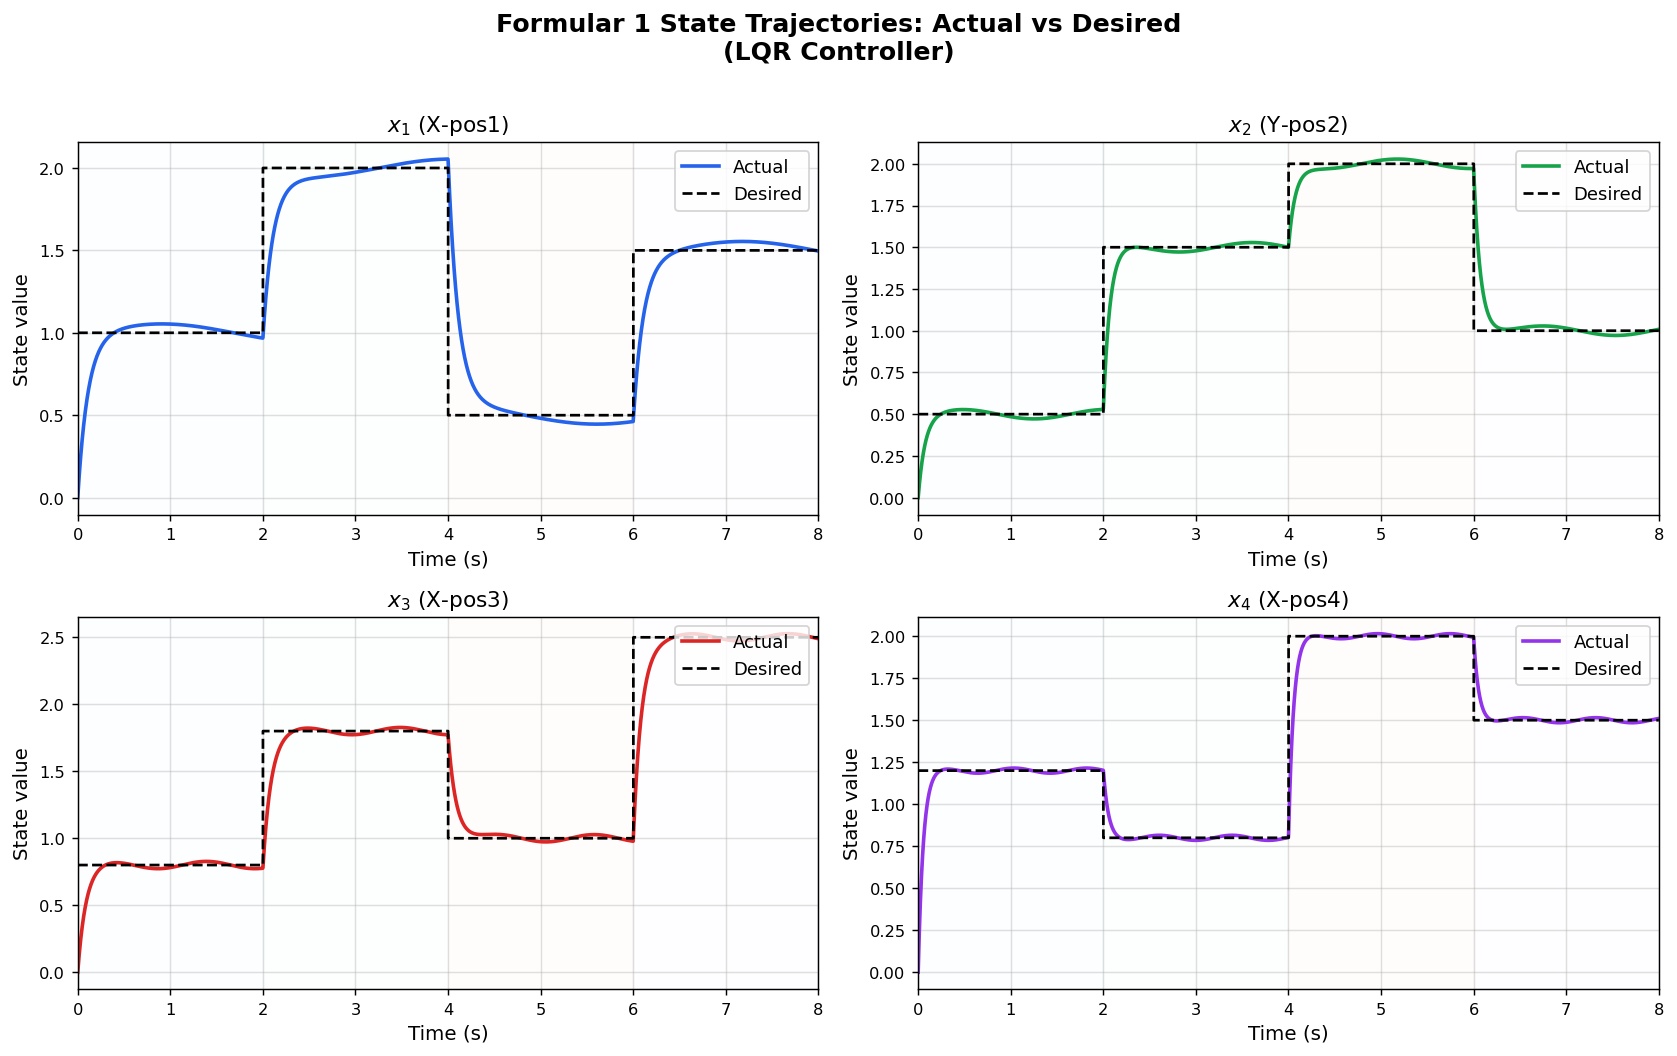

Saved: fig1_state_trajectories.png


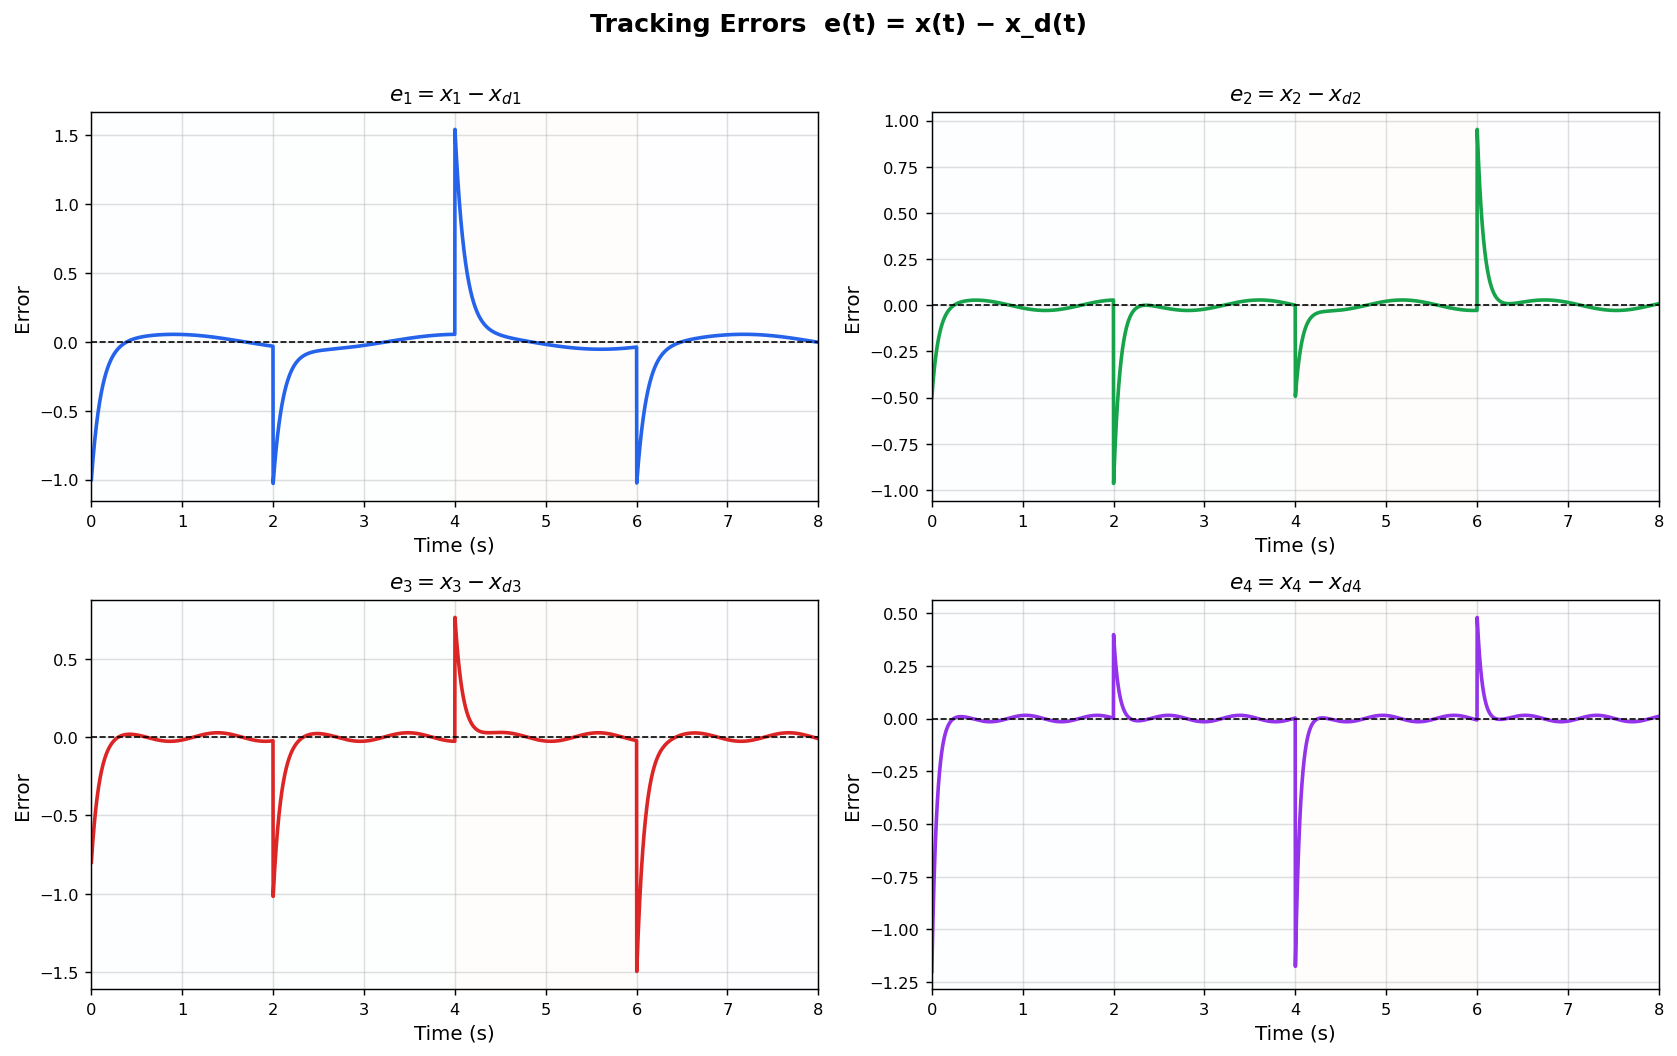

Saved: fig2_tracking_errors.png


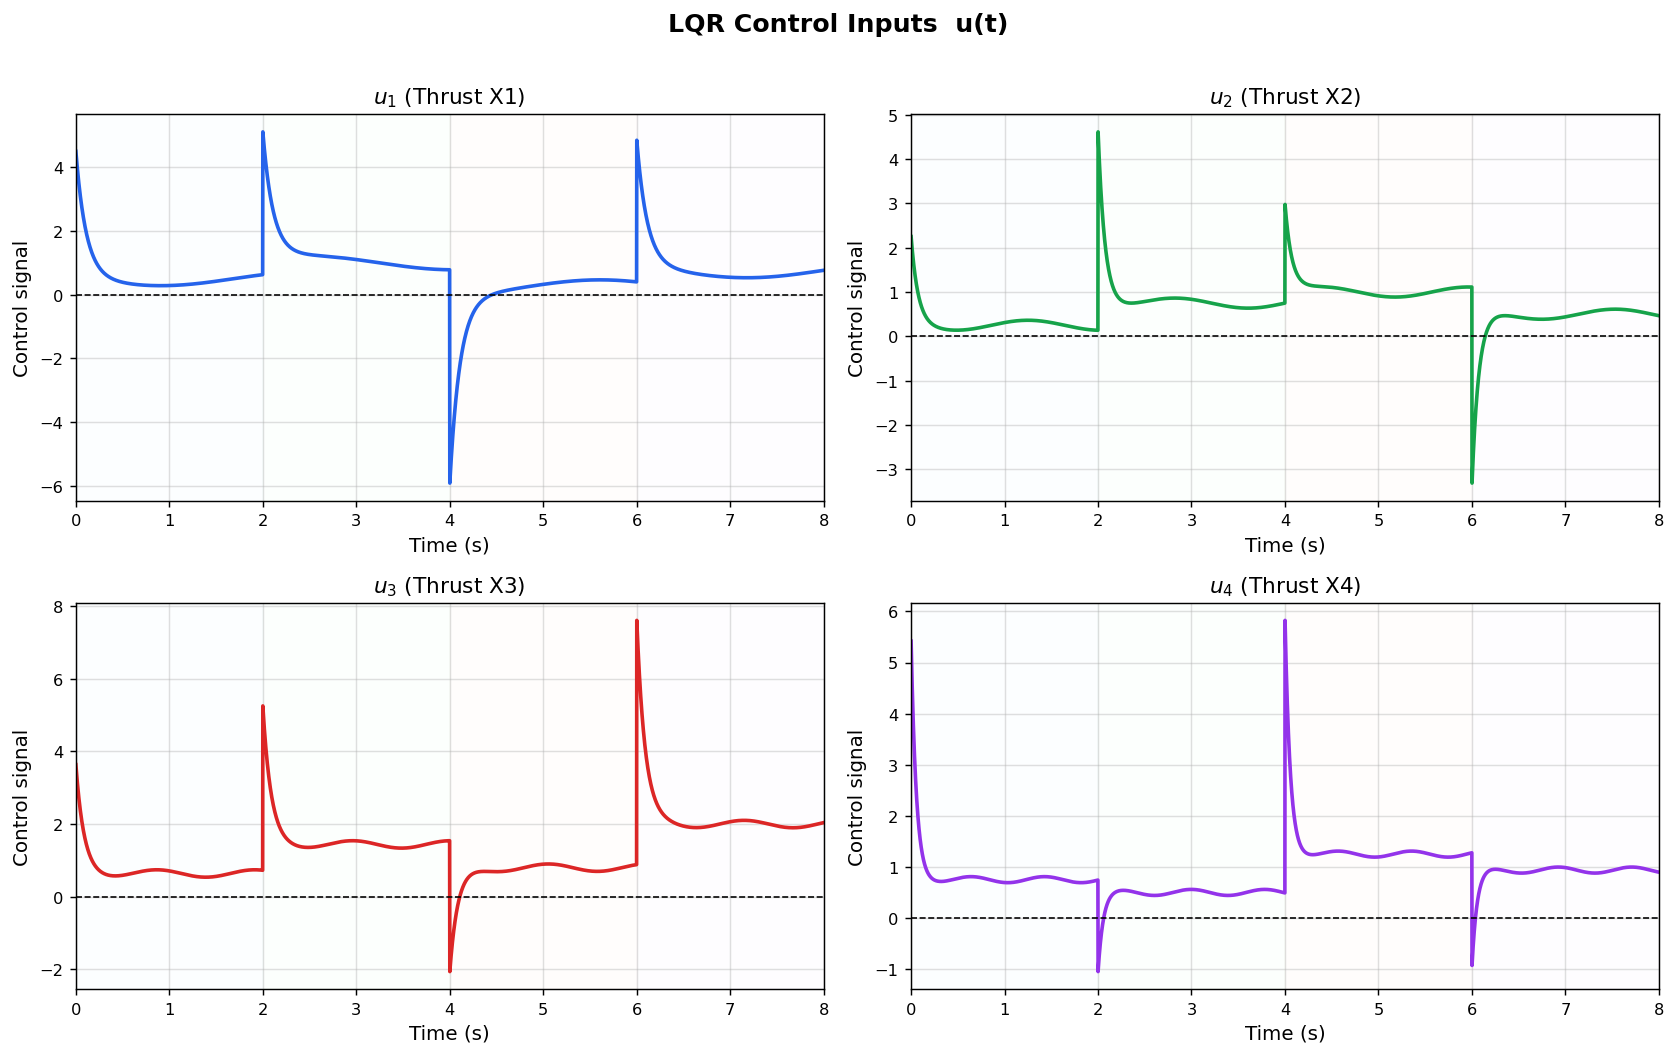

Saved: fig3_control_inputs.png


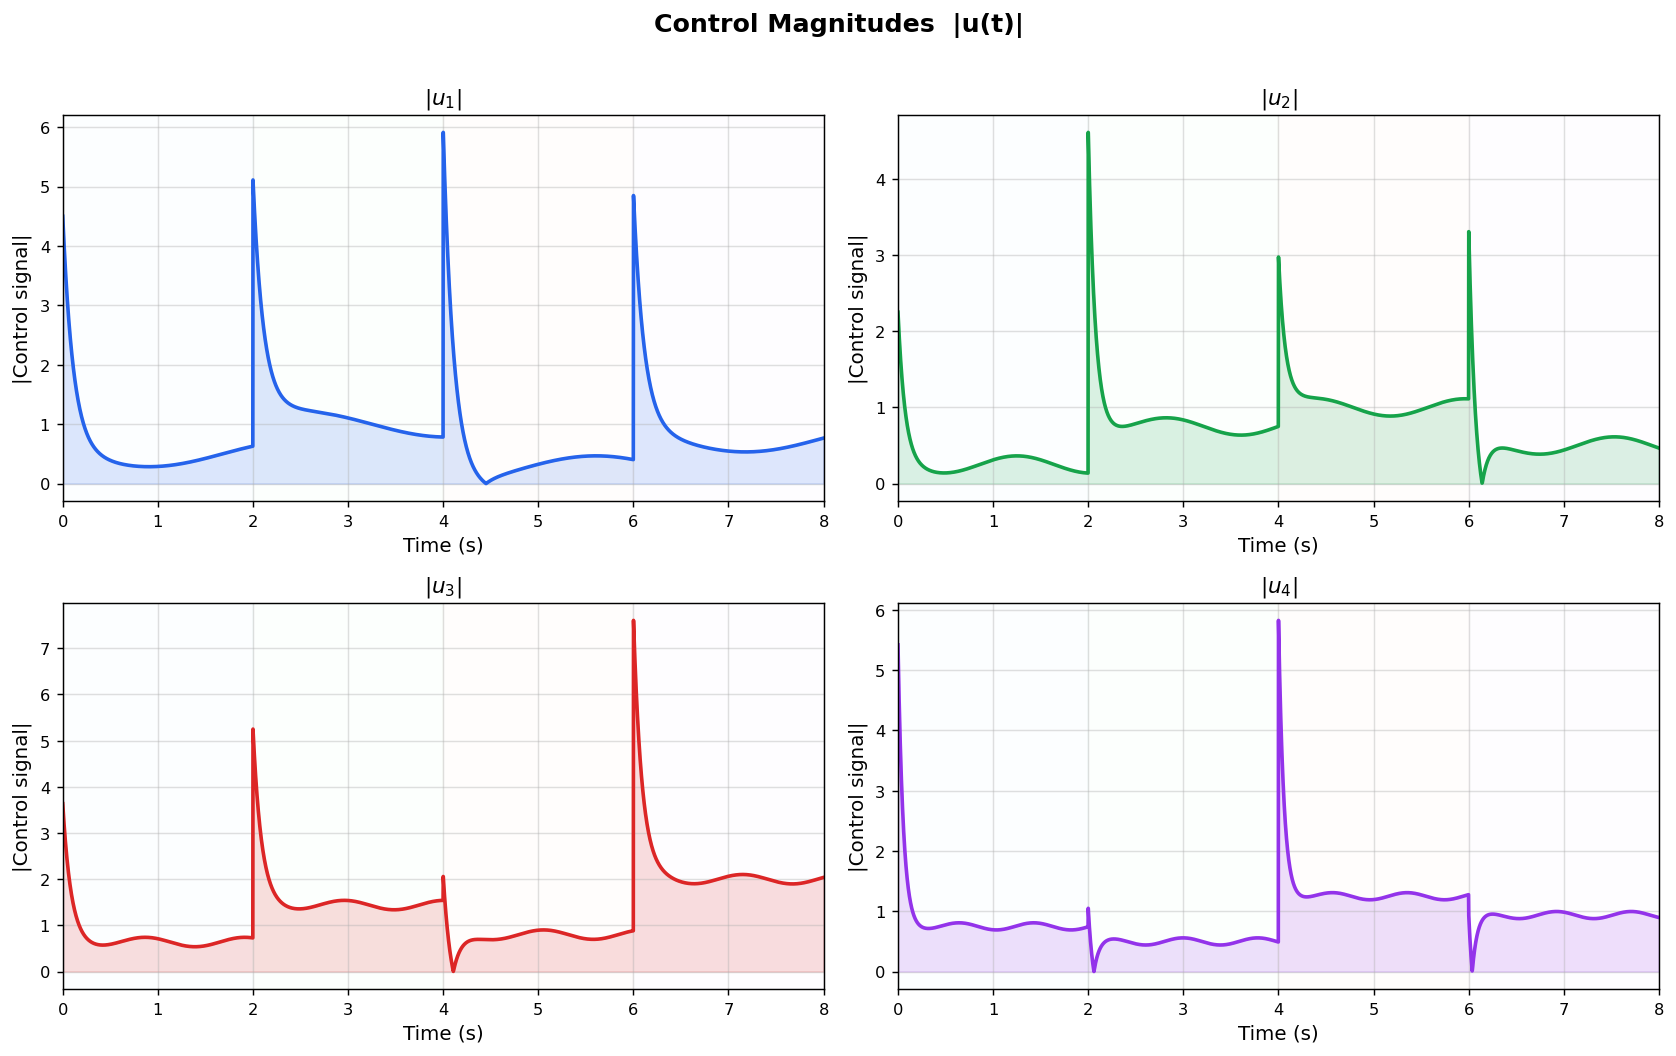

Saved: fig4_control_magnitudes.png


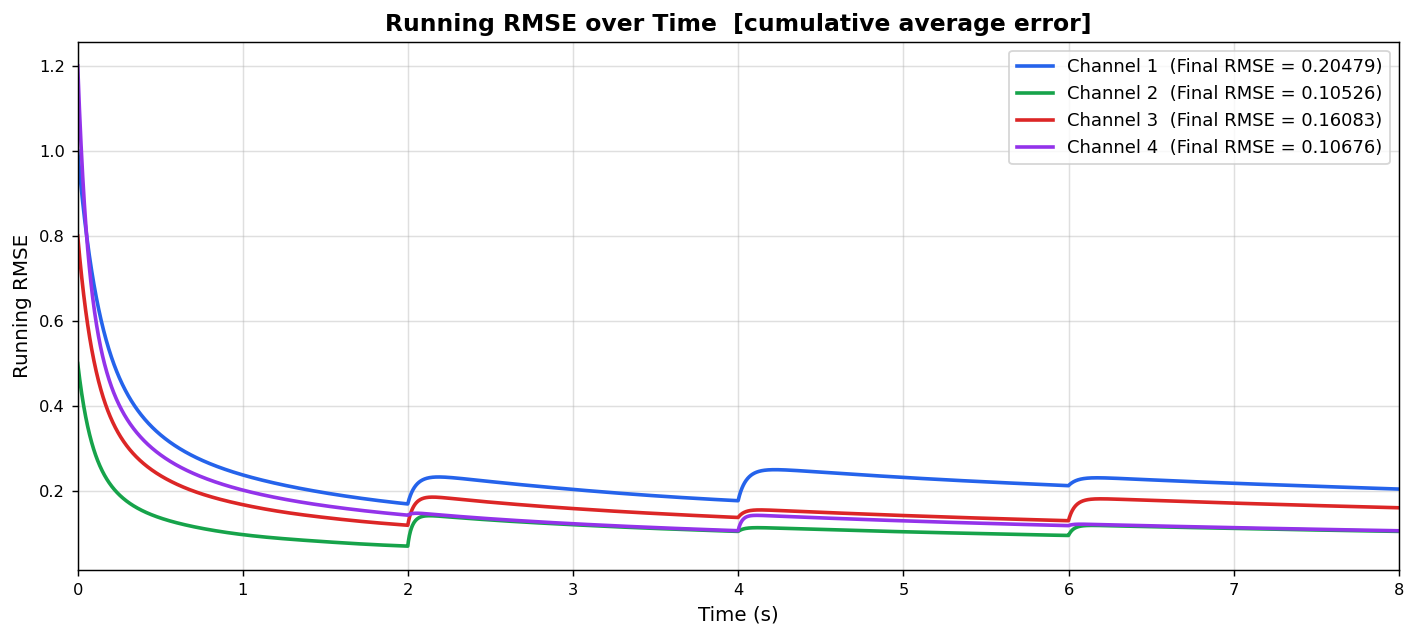

Saved: fig5_running_rmse.png


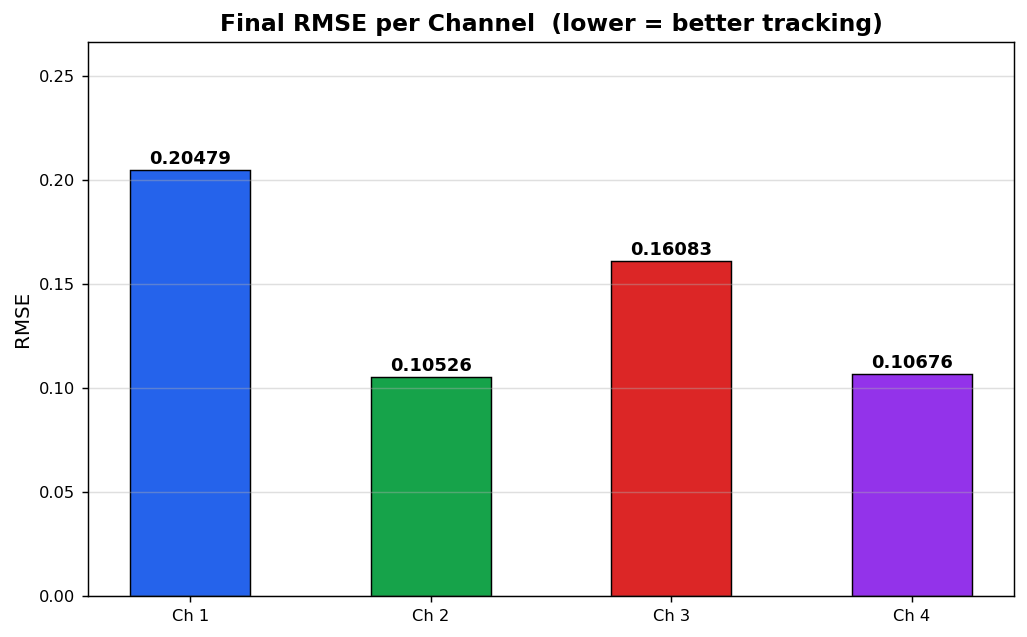

Saved: fig6_rmse_bar.png


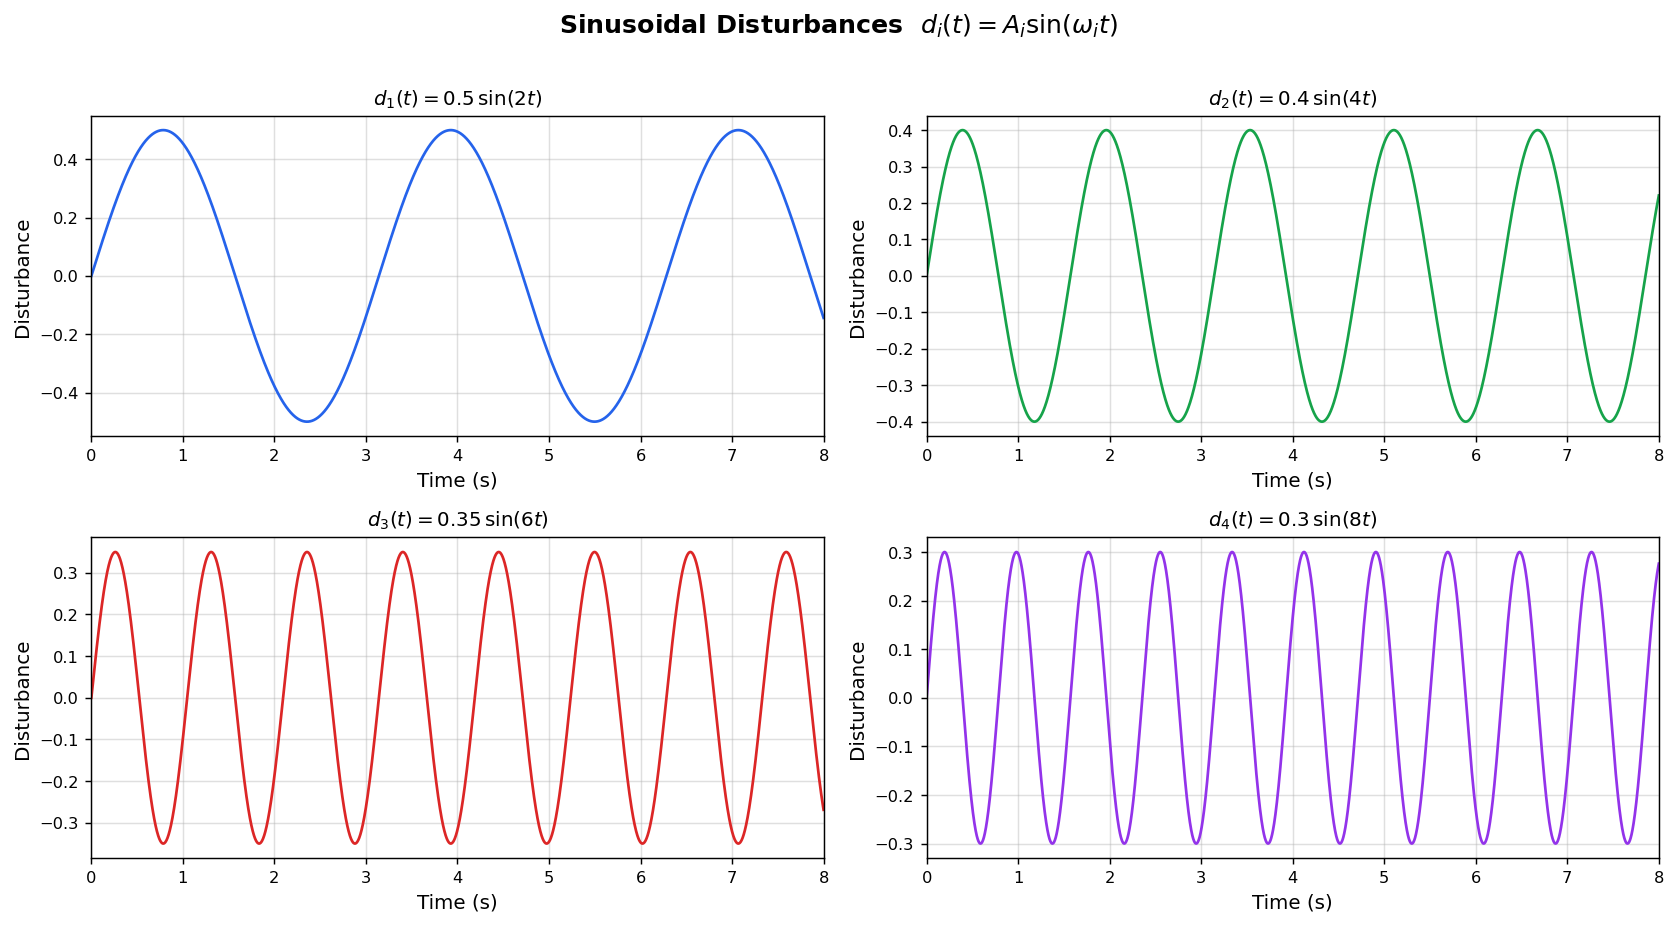

Saved: fig7_disturbances.png


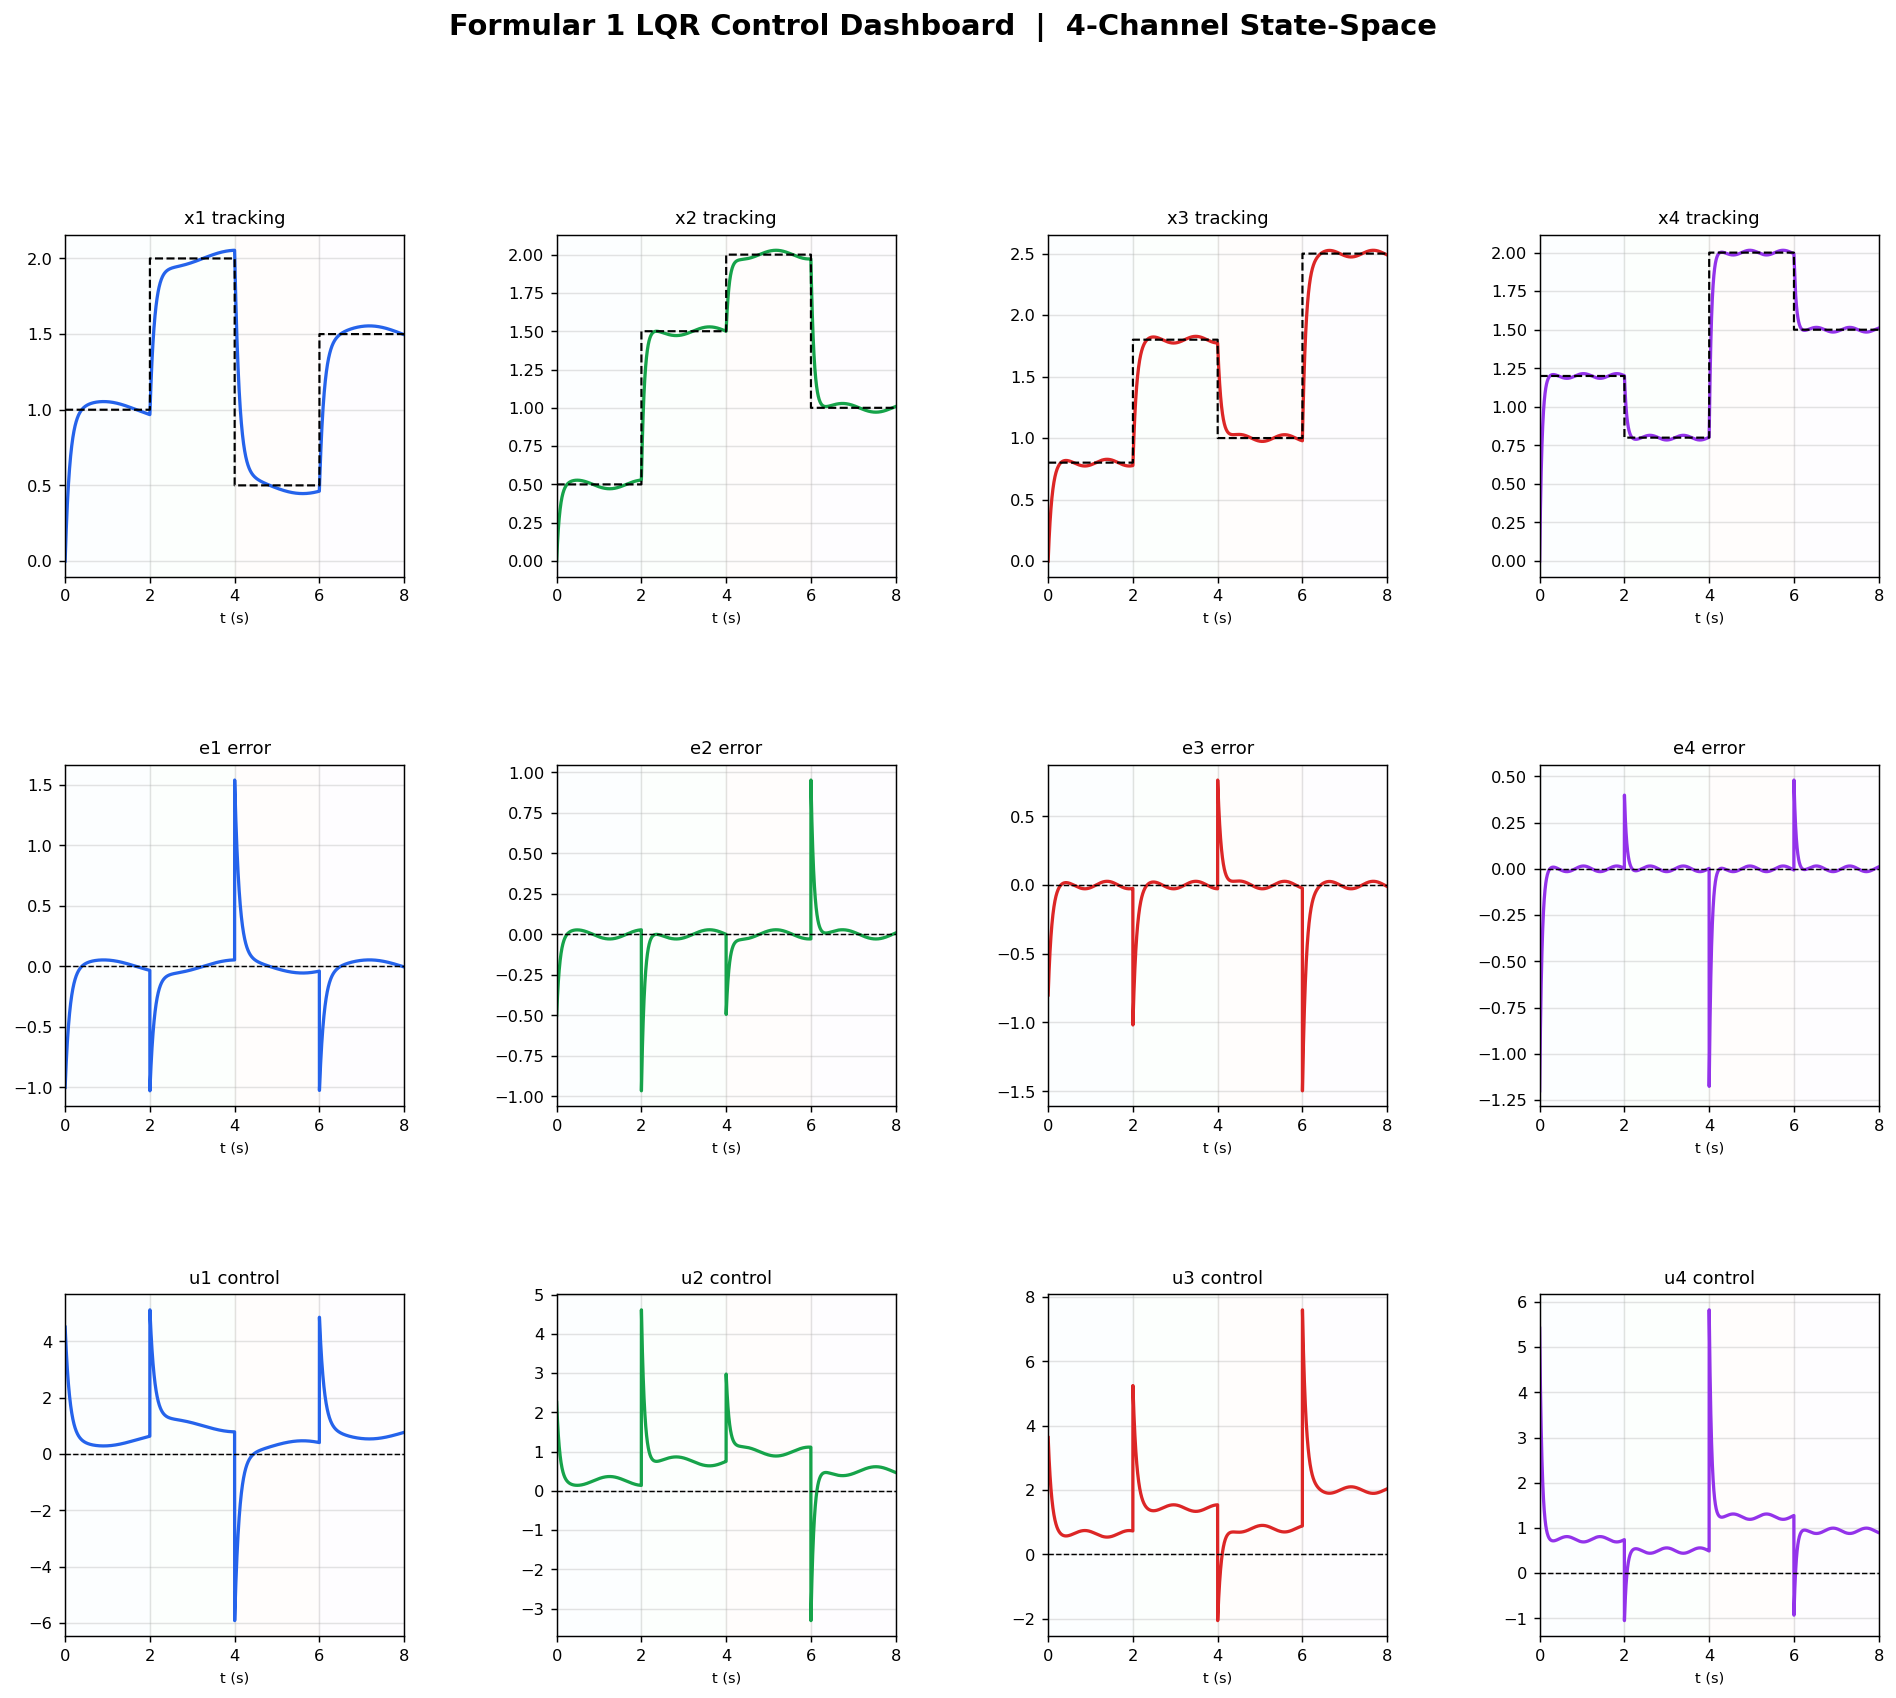

Saved: fig8_dashboard.png


In [82]:
# SECTION 11 – PLOTTING
# ─────────────────────────────────────────────────────────────────────────────
import os

# Create the output directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

# Helper to shade step regions

def shade_steps(ax):   # Lightly shade each step segment for visual clarity.

    shades = ["#F0F9FF", "#F0FFF4", "#FFF7ED", "#FDF4FF"]
    for k in range(len(STEPS)):
        ax.axvspan(STEP_TIMES[k], STEP_TIMES[k + 1],
                   alpha=0.15, color=shades[k % 4], zorder=0)

state_names  = [r"$x_1$ (X-pos1)", r"$x_2$ (Y-pos2)",
                r"$x_3$ (X-pos3)", r"$x_4$ (X-pos4)"]
error_names  = [r"$e_1 = x_1 - x_{d1}$", r"$e_2 = x_2 - x_{d2}$",
                r"$e_3 = x_3 - x_{d3}$", r"$e_4 = x_4 - x_{d4}$"]
ctrl_names   = [r"$u_1$ (Thrust X1)", r"$u_2$ (Thrust X2)",
                r"$u_3$ (Thrust X3)", r"$u_4$ (Thrust X4)"]
chmag_names  = [r"$|u_1|$", r"$|u_2|$", r"$|u_3|$", r"$|u_4|$"]


# ── FIGURE 1 : State Trajectories ──────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(13, 8))
fig1.suptitle("Formular 1 State Trajectories: Actual vs Desired\n(LQR Controller)",
              fontsize=14, fontweight="bold", y=1.01)
for i, ax in enumerate(axes1.flatten()):
    shade_steps(ax)
    ax.plot(t, x[i],        color=COLORS[i], lw=2,   label="Actual")
    ax.step(t, x_d_all[i],  color="black",   lw=1.5, linestyle="--",
            where="post",                              label="Desired")
    ax.set_title(state_names[i])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("State value")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.4)
    ax.set_xlim([0, T_END])
plt.tight_layout()
plt.savefig(output_dir + "fig1_state_trajectories.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_state_trajectories.png")

# ── FIGURE 2 : Tracking Errors ─────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(13, 8))
fig2.suptitle("Tracking Errors  e(t) = x(t) − x_d(t)",
              fontsize=14, fontweight="bold", y=1.01)
for i, ax in enumerate(axes2.flatten()):
    shade_steps(ax)
    ax.plot(t, error_all[i], color=COLORS[i], lw=2)
    ax.axhline(0, color="black", lw=0.9, linestyle="--")
    ax.set_title(error_names[i])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Error")
    ax.grid(True, alpha=0.4)
    ax.set_xlim([0, T_END])
plt.tight_layout()
plt.savefig(output_dir + "fig2_tracking_errors.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_tracking_errors.png")

# ── FIGURE 3 : Control Inputs ──────────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 2, figsize=(13, 8))
fig3.suptitle("LQR Control Inputs  u(t)",
              fontsize=14, fontweight="bold", y=1.01)
for i, ax in enumerate(axes3.flatten()):
    shade_steps(ax)
    ax.plot(t, u_all[i], color=COLORS[i], lw=2)
    ax.axhline(0, color="black", lw=0.9, linestyle="--")
    ax.set_title(ctrl_names[i])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Control signal")
    ax.grid(True, alpha=0.4)
    ax.set_xlim([0, T_END])
plt.tight_layout()
plt.savefig(output_dir + "fig3_control_inputs.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_control_inputs.png")

# ── FIGURE 4 : Control Magnitudes ──────────────────────────────────────────
fig4, axes4 = plt.subplots(2, 2, figsize=(13, 8))
fig4.suptitle("Control Magnitudes  |u(t)|",
              fontsize=14, fontweight="bold", y=1.01)
for i, ax in enumerate(axes4.flatten()):
    shade_steps(ax)
    ax.plot(t, np.abs(u_all[i]), color=COLORS[i], lw=2)
    ax.fill_between(t, 0, np.abs(u_all[i]),
                    color=COLORS[i], alpha=0.15)
    ax.set_title(chmag_names[i])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("|Control signal|")
    ax.grid(True, alpha=0.4)
    ax.set_xlim([0, T_END])
plt.tight_layout()
plt.savefig(output_dir + "fig4_control_magnitudes.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_control_magnitudes.png")

# ── FIGURE 5 : Running RMSE over time ──────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(11, 5))
for i in range(4):
    ax5.plot(t, running_rmse[i], color=COLORS[i], lw=2,
             label=f"Channel {i+1}  (Final RMSE = {rmse_total[i]:.5f})")
ax5.set_title("Running RMSE over Time  [cumulative average error]",
              fontsize=13, fontweight="bold")
ax5.set_xlabel("Time (s)")
ax5.set_ylabel("Running RMSE")
ax5.legend()
ax5.grid(True, alpha=0.4)
ax5.set_xlim([0, T_END])
plt.tight_layout()
plt.savefig(output_dir + "fig5_running_rmse.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_running_rmse.png")

# ── FIGURE 6 : RMSE Bar Chart ──────────────────────────────────────────────
fig6, ax6 = plt.subplots(figsize=(8, 5))
bars = ax6.bar(
    [f"Ch {i+1}" for i in range(4)],
    rmse_total,
    color=COLORS, edgecolor="black", linewidth=0.8, width=0.5
)
for bar, val in zip(bars, rmse_total):
    ax6.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.001,
             f"{val:.5f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax6.set_title("Final RMSE per Channel  (lower = better tracking)",
              fontsize=13, fontweight="bold")
ax6.set_ylabel("RMSE")
ax6.set_ylim([0, max(rmse_total) * 1.3])
ax6.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(output_dir + "fig6_rmse_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig6_rmse_bar.png")

# ── FIGURE 7 : Disturbance signals ─────────────────────────────────────────
fig7, axes7 = plt.subplots(2, 2, figsize=(13, 7))
fig7.suptitle(r"Sinusoidal Disturbances  $d_i(t) = A_i \sin(\omega_i t)$",
              fontsize=14, fontweight="bold", y=1.01)
for i, ax in enumerate(axes7.flatten()):
    ax.plot(t, d_all[i], color=COLORS[i], lw=1.5)
    ax.set_title(
        rf"$d_{i+1}(t) = {A_amp[i]}\,\sin({int(omega[i])}t)$",
        fontsize=11
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Disturbance")
    ax.grid(True, alpha=0.4)
    ax.set_xlim([0, T_END])
plt.tight_layout()
plt.savefig(output_dir + "fig7_disturbances.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig7_disturbances.png")

# ── FIGURE 8 : Combined Dashboard ──────────────────────────────────────────
fig8 = plt.figure(figsize=(18, 14))
fig8.suptitle("Formular 1 LQR Control Dashboard  |  4-Channel State-Space",
              fontsize=16, fontweight="bold", y=1.002)

gs = gridspec.GridSpec(3, 4, figure=fig8, hspace=0.55, wspace=0.45)

for i in range(4):
    # Row 0: state tracking
    ax = fig8.add_subplot(gs[0, i])
    shade_steps(ax)
    ax.plot(t, x[i],        color=COLORS[i], lw=1.8)
    ax.step(t, x_d_all[i],  color="black",   lw=1.2, linestyle="--", where="post")
    ax.set_title(f"x{i+1} tracking", fontsize=10)
    ax.set_xlabel("t (s)", fontsize=8)
    ax.grid(True, alpha=0.35)
    ax.set_xlim([0, T_END])

    # Row 1: tracking error
    ax = fig8.add_subplot(gs[1, i])
    shade_steps(ax)
    ax.plot(t, error_all[i], color=COLORS[i], lw=1.8)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(f"e{i+1} error", fontsize=10)
    ax.set_xlabel("t (s)", fontsize=8)
    ax.grid(True, alpha=0.35)
    ax.set_xlim([0, T_END])

    # Row 2: control
    ax = fig8.add_subplot(gs[2, i])
    shade_steps(ax)
    ax.plot(t, u_all[i], color=COLORS[i], lw=1.8)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(f"u{i+1} control", fontsize=10)
    ax.set_xlabel("t (s)", fontsize=8)
    ax.grid(True, alpha=0.35)
    ax.set_xlim([0, T_END])

plt.savefig(output_dir + "fig8_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig8_dashboard.png")

In [84]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12 – SUMMARY REPORT
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("          SIMULATION SUMMARY REPORT")
print("=" * 60)
print(f"  Simulation time   : 0 → {T_END} s")
print(f"  Sample points     : {N}")
print(f"  ODE method        : RK45")
print(f"  Initial state x0  : {x0}")
print()
print("  System matrices:")
print(f"    A diagonal = {a_diag}")
print(f"    B diagonal = {b_diag}")
print()
print("  LQR gains (diagonal of K):")
print(f"    {np.round(np.diag(K), 4)}")
print()
print("  Closed-loop poles (A − BK diagonal):")
cl_d = a_diag - b_diag * np.diag(K)   # valid because both are diagonal
print(f"    {np.round(cl_d, 4)}")
print()
print("  Disturbances: Aᵢ·sin(ωᵢt)")
print(f"    Amplitudes : {D_amp}")
print(f"    Frequencies: {omega} rad/s")
print()
print("  RMSE per channel:")
for i in range(4):
    bar = "█" * int(rmse_total[i] / max(rmse_total) * 20)
    print(f"    Channel {i+1}: {rmse_total[i]:.6f}  {bar}")
print()
print("  Output figures saved to /mnt/user-data/outputs/")
print("=" * 60)


          SIMULATION SUMMARY REPORT
  Simulation time   : 0 → 8.0 s
  Sample points     : 4000
  ODE method        : RK45
  Initial state x0  : [0. 0. 0. 0.]

  System matrices:
    A diagonal = [-1.  -1.5 -2.  -2.5]
    B diagonal = [2.  3.  2.5 4. ]

  LQR gains (diagonal of K):
    [4.     4.     3.7431 3.8906]

  Closed-loop poles (A − BK diagonal):
    [ -9.     -13.5    -11.3578 -18.0624]

  Disturbances: Aᵢ·sin(ωᵢt)
    Amplitudes : [0.5  0.4  0.35 0.3 ]
    Frequencies: [2. 4. 6. 8.] rad/s

  RMSE per channel:
    Channel 1: 0.204788  ████████████████████
    Channel 2: 0.105255  ██████████
    Channel 3: 0.160826  ███████████████
    Channel 4: 0.106756  ██████████

  Output figures saved to /mnt/user-data/outputs/
